### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.optimize import minimize
from matplotlib import rcParams
import pickle
from scipy.stats import truncnorm

In [2]:
plt.rcParams['font.family'] = 'Charter'

## Load All Data

In [15]:
data_folder = '/Users/philvanlane/Documents/lc_ae/data/'

all_stars = pd.read_csv(data_folder + 'all_stars_dist.csv',dtype={'Gaiadr3_id':str})

## Dustmap Setup

In [4]:
from dustmaps.bayestar import BayestarQuery
from dustmaps.edenhofer2023 import Edenhofer2023Query
from dustmaps.config import config

In [5]:
config['data_dir'] = '/Users/philvanlane/opt/anaconda3/lib/python3.9/site-packages/dustmaps/data'

In [6]:
edenhofer = Edenhofer2023Query(load_samples=True,integrated=False,seed=19)

Optimizing map for querying (this might take a couple of seconds)...


In [7]:
ed = edenhofer.distances / (1*u.pc)
ed[0] = ed[0] + 0.0001
ed[-1] = ed[-1] - 0.0001

In [8]:
ed

<Quantity [  68.81197 ,   69.19981 ,   69.58993 ,   69.98224 ,   70.37677 ,
             70.77352 ,   71.172516,   71.57375 ,   71.97726 ,   72.38303 ,
             72.79109 ,   73.20146 ,   73.614136,   74.029144,   74.44649 ,
             74.86618 ,   75.288246,   75.712685,   76.13952 ,   76.56876 ,
             77.00042 ,   77.43452 ,   77.87106 ,   78.31007 ,   78.75154 ,
             79.1955  ,   79.641975,   80.090965,   80.54248 ,   80.996544,
             81.45316 ,   81.91236 ,   82.37415 ,   82.83854 ,   83.30555 ,
             83.775185,   84.247475,   84.72243 ,   85.20005 ,   85.680374,
             86.1634  ,   86.649155,   87.13764 ,   87.62888 ,   88.1229  ,
             88.6197  ,   89.11929 ,   89.62171 ,   90.12696 ,   90.635056,
             91.14602 ,   91.65986 ,   92.1766  ,   92.69624 ,   93.21883 ,
             93.744354,   94.27284 ,   94.80431 ,   95.338776,   95.87626 ,
             96.41676 ,   96.96032 ,   97.50694 ,   98.05664 ,   98.60944 ,
            

In [9]:
bayestar = BayestarQuery(max_samples=10)

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 32.599 s
  pix_info:   0.403 s
   samples:  15.387 s
      best:   3.008 s
       nan:   0.046 s
      sort:  13.677 s
       idx:   0.078 s


## Samples from dustmaps

In [10]:
num_dist_samples = 10

### Only Bayestar

In [11]:
coord = SkyCoord(60*u.deg, 60*u.deg, distance=200*u.pc, frame='icrs')
E = bayestar(coord,mode='samples',return_flags=True)

In [12]:
E[1]

(True, False)

In [383]:
if (E[1][0] & E[1][0]):
    print('true')

true


In [389]:
samples_bayestar_withqa = {}

for i,r in all_stars.iterrows():
    
    if i % 1000 == 0:
        print('Starting row: ' + str(i))
    
    gid = str(r.GaiaDR3_ID)
    par = r.dr3_parallax_corrected
    par_std = r.dr3_parallax_corrected * r.frac_parallax_err
    par_samples = np.random.normal(par,par_std,num_dist_samples)
    dist_samples = 1000/par_samples
    dist_samples = np.sort(dist_samples)
    
    # E samples
    
    b_all_samples = []
    
    # Getting E for each distance
    
    for i in range(len(dist_samples)):
        d = dist_samples[i]
        if d>= 0:
            
            # Bayestar
            
            coord = SkyCoord(r.ra*u.deg, r.dec*u.deg, distance=d*u.pc, frame='icrs')
            E = bayestar(coord,mode='samples',return_flags=True)
            qa_flags = E[1]
            if (qa_flags[0] & qa_flags[1]):
                for e in E[0]:
                    b_all_samples.append(e)
                
                
    b_all_samples = np.array(b_all_samples)

    # Add to dict
    
    samples_bayestar_withqa[gid] = {
        'ra': r.ra,
        'dec': r.dec,
        'dist_samples': dist_samples,
        'E_samples_Bayestar': b_all_samples
    }

Starting row: 0
Starting row: 1000
Starting row: 2000
Starting row: 3000
Starting row: 4000
Starting row: 5000
Starting row: 6000
Starting row: 7000
Starting row: 8000
Starting row: 9000
Starting row: 10000
Starting row: 11000
Starting row: 12000
Starting row: 13000
Starting row: 14000
Starting row: 15000
Starting row: 16000
Starting row: 17000
Starting row: 18000
Starting row: 19000
Starting row: 20000
Starting row: 21000
Starting row: 22000
Starting row: 23000
Starting row: 24000
Starting row: 25000
Starting row: 26000
Starting row: 27000
Starting row: 28000
Starting row: 29000
Starting row: 30000


In [390]:
for gid in samples_bayestar_withqa.keys():
    samples_bayestar_withqa[gid]['dist_avg'] = np.nanmean(samples_bayestar_withqa[gid]['dist_samples'])
    samples_bayestar_withqa[gid]['E_Bayestar_med'] = np.nanmedian(samples_bayestar_withqa[gid]['E_samples_Bayestar'])
    samples_bayestar_withqa[gid]['E_Bayestar_std'] = np.nanstd(samples_bayestar_withqa[gid]['E_samples_Bayestar'])

/Users/philvanlane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1117: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/philvanlane/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1670: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Both Bayestar and Edenhofer

In [11]:
all_stars['frac_parallax_err'] = all_stars['parallax_error'] / all_stars['parallax_zpt_corrected']
all_stars['dist_from_par_corr'] = 1000 / all_stars['parallax_zpt_corrected']

In [12]:
df_to_use = all_stars.loc[all_stars['frac_parallax_err'] < 0.2]

In [15]:
all_stars.sort_values('frac_parallax_err', inplace=True)

In [16]:
df_to_use = all_stars

In [17]:
df_to_use.keys()

Index(['Gaiadr3_id', 'ra', 'dec', 'parallax_original',
       'parallax_zpt_corrected', 'parallax_error', 'dist_pc', 'dist_pc_err',
       'dist_ref'],
      dtype='object')

In [18]:
len(df_to_use)

24072

In [19]:
samples_new = {}

for i,r in df_to_use.iterrows():
    
    if i % 500 == 0:
        print('Starting row: ' + str(i))
    
    gid = str(r.Gaiadr3_id)
    dist = r.dist_pc
    dist_err = r.dist_pc_err
    # par = r.parallax_zpt_corrected
    # par_std = r.parallax_zpt_corrected * r.frac_parallax_err
    # par_samples = np.random.normal(par,par_std,num_dist_samples)
    # dist_samples = 1000/par_samples
    # dist_samples = np.sort(dist_samples)
    dist_samples = np.random.normal(dist, dist_err, num_dist_samples)
    
    # E samples
    
    b_all_samples = []
    e_all_samples = []
    
    
    # Getting integrated Edenhofer values
    
    max_dist = np.max(dist_samples)

    if max_dist > 0:
        ed_sub = [dist for dist in ed if dist <= max_dist]
        ed_sub.append(max_dist)

        eden_E = []

        for i2 in range(len(ed_sub)):
            coords = SkyCoord(r.ra*u.deg,r.dec*u.deg,ed_sub[i2]*u.pc,frame='icrs')
            eden_E.append(edenhofer(coords,mode='samples'))

        eden_E = np.array(eden_E)
    
    # Getting E for each distance
    
    for i in range(len(dist_samples)):
        d = dist_samples[i]
        if d>= 0:
            
            # Bayestar
            
            coord = SkyCoord(r.ra*u.deg, r.dec*u.deg, distance=d*u.pc, frame='icrs')
            E = bayestar(coord,mode='samples',return_flags=True)
            qa_flags = E[1]
            if (qa_flags[0] & qa_flags[1]):
                for e in E[0]:
                    b_all_samples.append(e)
                
                
            # Edenhofer

            index = np.searchsorted(ed_sub, dist_samples[i])

            # Slice x and y arrays up to this index
            if ed_sub[index] == dist_samples[i]:
                x_sub = ed_sub[:index+1]
                y_sub = eden_E[:index]

            # If x_limit is not exactly in the array, we interpolate the last point
            else:
                x_sub = ed_sub[:index]
                y_sub = eden_E[:index]
                x_sub = np.append(x_sub, dist_samples[i])

            for q in range(12):
                y_sub_ind_sample = y_sub[:,q]
                y_sub_ind_sample = np.append(y_sub_ind_sample,
                                             np.interp(dist_samples[i], ed_sub, eden_E[:,q]))

                # Perform the integration
                result = np.trapz(y_sub_ind_sample, x_sub)
                e_all_samples.append(np.trapz(y=y_sub_ind_sample,x=x_sub))

    b_all_samples = np.array(b_all_samples)
    e_all_samples = np.array(e_all_samples)
    
    # Add to dict
    
    samples_new[gid] = {
        'ra': r.ra,
        'dec': r.dec,
        'dist_samples': dist_samples,
        'E_samples_Bayestar': b_all_samples,
        'E_samples_Edenhofer': e_all_samples
    }

Starting row: 0
Starting row: 500
Starting row: 1000
Starting row: 1500
Starting row: 2000
Starting row: 2500
Starting row: 3000
Starting row: 3500
Starting row: 4000
Starting row: 4500
Starting row: 5000
Starting row: 5500
Starting row: 6000
Starting row: 6500
Starting row: 7000
Starting row: 7500
Starting row: 8000
Starting row: 8500
Starting row: 9000
Starting row: 9500
Starting row: 10000
Starting row: 10500
Starting row: 11000
Starting row: 11500
Starting row: 12000
Starting row: 12500
Starting row: 13000
Starting row: 13500
Starting row: 14000
Starting row: 14500
Starting row: 15000
Starting row: 15500
Starting row: 16000
Starting row: 16500
Starting row: 17000
Starting row: 17500
Starting row: 18000
Starting row: 18500
Starting row: 19000
Starting row: 19500
Starting row: 20000
Starting row: 20500
Starting row: 21000
Starting row: 21500
Starting row: 22000
Starting row: 22500
Starting row: 23000
Starting row: 23500
Starting row: 24000


In [ ]:
print

In [25]:
samples_new.keys()

dict_keys(['3946945413106333696', '1696798367260229376', '1920113512486282240', '1385293808145621504', '2135550755683407232', '4342464209753404416', '1756741374681702784', '6243841249531772800', '1603662211901473408', '3830897080395058048', '5040416186560252416', '4963614887043956096', '5183875103632956032', '51369428065705600', '151499478104075008', '146487556211644544', '5201185574182015744', '5199985216726016896', '3459372646830687104', '6045818685674325760', '2080063931448749824', '6348514275456913792', '1986772848034988544', '2837047214379099904', '1092230803512999424', '777254360337133312', '3205095125321700480', '2835207319109249920', '704967037090946688', '704966762213039488', '1004358968092652544', '3507879565090229888', '2939555954755196160', '3740176925743994752', '2500064286492779264', '1700658653802527104', '2495420602212048640', '2630155547353593216', '156917493449670656', '5495052596695570816', '3009908378049913216', '6794047652729201024', '6105713692544123520', '4472832

### Using cluster distance parameters

In [47]:
# Hardcoding for NGC2516

In [50]:
df_cl_sub = all_stars.loc[(all_stars['frac_parallax_err'] >= 0.2)
                         | (np.isnan(all_stars['frac_parallax_err']))]

In [51]:
df_cl_sub

,GaiaDR3_ID,ra,ra_error,dec,dec_error,parallax,parallax_error,bp_rp,phot_g_mean_mag,azero_gspphot,...,pseudocolour,ecl_lat,astrometric_params_solved,frac_parallax_err,zpt_corr,dr3_parallax_corrected,phot_g_mag_err_calc,phot_bp_mag_err_calc,phot_rp_mag_err_calc,dist_from_par_corr
31,5290669328010253952,119.723560,1.803181,-60.942276,1.671682,NaN,NaN,2.610153,17.906809,NaN,...,NaN,-75.877577,3,NaN,NaN,NaN,0.006357,0.028030,0.005716,NaN
114,5290735676668773504,119.038427,0.570704,-60.793299,0.518206,0.040626,0.571644,2.600174,17.417685,NaN,...,NaN,-76.057620,31,14.070891,-0.033991,0.074617,0.007222,0.020861,0.003053,13401.769184


In [52]:
samples_cl_subs = {}

for i,r in df_cl_sub.iterrows():
    
    if i % 50 == 0:
        print('Starting row: ' + str(i))
    
    gid = str(r.GaiaDR3_ID)
#     cl_dist = r.dist_avg
#     dist_samples = np.random.normal(cl_dist,r.dist_err,num_dist_samples)
#     dist_samples = np.sort(dist_samples)
    
    # Using average cluster parallax etc...
    par = 2.443845891969311
    par_std = par * 0.06761900320751713
    par_samples = np.random.normal(par,par_std,num_dist_samples)
    dist_samples = 1000/par_samples
    dist_samples = np.sort(dist_samples)
    
    # E samples
    
    b_all_samples = []
    e_all_samples = []
    
    
    # Getting integrated Edenhofer values
    
    max_dist = np.max(dist_samples)

    ed_sub = [dist for dist in ed if dist <= max_dist]
    ed_sub.append(max_dist)
    
    eden_E = []
    
    for i2 in range(len(ed_sub)):
        coords = SkyCoord(r.ra*u.deg,r.dec*u.deg,ed_sub[i2]*u.pc,frame='icrs')
        eden_E.append(edenhofer(coords,mode='samples'))

    eden_E = np.array(eden_E)
    
    # Getting E for each distance
    
    for i in range(len(dist_samples)):
        d = dist_samples[i]
        if d>= 0:
            
            # Bayestar
            
            coord = SkyCoord(r.ra*u.deg, r.dec*u.deg, distance=d*u.pc, frame='icrs')
            E = bayestar(coord,mode='samples',return_flags=True)
            qa_flags = E[1]
            if (qa_flags[0] & qa_flags[1]):
                for e in E[0]:
                    b_all_samples.append(e)
                
                
            # Edenhofer

            index = np.searchsorted(ed_sub, dist_samples[i])

            # Slice x and y arrays up to this index
            if ed_sub[index] == dist_samples[i]:
                x_sub = ed_sub[:index+1]
                y_sub = eden_E[:index]

            # If x_limit is not exactly in the array, we interpolate the last point
            else:
                x_sub = ed_sub[:index]
                y_sub = eden_E[:index]
                x_sub = np.append(x_sub, dist_samples[i])

            for q in range(12):
                y_sub_ind_sample = y_sub[:,q]
                y_sub_ind_sample = np.append(y_sub_ind_sample,
                                             np.interp(dist_samples[i], ed_sub, eden_E[:,q]))

                # Perform the integration
                result = np.trapz(y_sub_ind_sample, x_sub)
                e_all_samples.append(np.trapz(y=y_sub_ind_sample,x=x_sub))

    b_all_samples = np.array(b_all_samples)
    e_all_samples = np.array(e_all_samples)
    
    # Add to dict
    
    samples_cl_subs[gid] = {
        'ra': r.ra,
        'dec': r.dec,
        'dist_samples': dist_samples,
        'E_samples_Bayestar': b_all_samples,
        'E_samples_Edenhofer': e_all_samples
    }

In [53]:
samples_new = samples_cl_subs

In [26]:
for gid in samples_new.keys():
    samples_new[gid]['dist_avg'] = np.nanmean(samples_new[gid]['dist_samples'])

In [27]:
for gid in samples_new.keys():
    samples_new[gid]['E_Bayestar_med'] = np.nanmedian(samples_new[gid]['E_samples_Bayestar'])
    samples_new[gid]['E_Bayestar_std'] = np.nanstd(samples_new[gid]['E_samples_Bayestar'])

/Users/philvanlane/opt/anaconda3/envs/default-py312/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/philvanlane/opt/anaconda3/envs/default-py312/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [28]:
for gid in samples_new.keys():
    samples_new[gid]['E_Edenhofer_med'] = np.nanmedian(samples_new[gid]['E_samples_Edenhofer'])
    samples_new[gid]['E_Edenhofer_std'] = np.nanstd(samples_new[gid]['E_samples_Edenhofer'])

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_19881/2379412155.py:2: RuntimeWarning: All-NaN slice encountered
  samples_new[gid]['E_Edenhofer_med'] = np.nanmedian(samples_new[gid]['E_samples_Edenhofer'])


#### De-reddening corrections

Converting extinction in E units from dust maps to E(B-V):

$$E(B-V) = 0.829 \times E_{Edenhofer2023}$$

$$E(B-V) = 0.88 \times E_{Bayestar2019}$$

We adopt a $R_V$ value of 3.1 in the following:

$$A_V = R_V \times E(B-V)$$

Gaia band conversion constants:

$$A_G = (0.789 \pm 0.005) \times A_V$$

$$A_{G_{BP}} = (1.002 \pm 0.007) \times A_V$$

$$A_{G_{RP}} = (0.589 \pm 0.004) \times A_V$$


I then re-calculate the Gaia fluxes for each band _b_ by applying:

$$F_{de-red,b} = F_{obs} \times 10^{0.4A_b}$$

I do this instead of simply adding/subtracting the magnitudes because uncertainties on Gaia fluxes are provided, however uncertainties on the magnitude values are not, and flux is the more direct observational measurement.

I then convert these de-reddened fluxed back to de-reddened magnitudes by applying:

$$G_{de-red,b} = -2.5 \times \log(\frac{F_{de-red,b}}{F_{zpt,b}})$$

where $F_{zpt,b}$ is the Gaia zeropoint flux for each band.

We can then calculated de-reddened colours using:

$$(G_{BP} - G_{RP})_0 = G_{de-red,BP} - G_{de-red,RP}$$

Uncertainties are propagated throughout these calculations where available. The raw sources of uncertainty are:

$\sigma_E$: The standard deviation of sample E values from the dustmap.

$\sigma_{A_b}$: The uncertainties on the $A_V$ to $A_b$ conversion constants as supplied in literature.

$\sigma_{F_{obs,b}}$: The reported uncertainties on Gaia fluxes for each band.



## Getting Av

In [29]:
# Conversion constants from table 3 of Wang & Chen (and standard values)

Rv = 3.1

A_GBP_div_Av = 1.002
A_GBP_div_Av_err = 0.007
A_GBP_div_Av_frac_err = A_GBP_div_Av_err / A_GBP_div_Av

A_GRP_div_Av = 0.589
A_GRP_div_Av_err = 0.004
A_GRP_div_Av_frac_err = A_GRP_div_Av_err / A_GRP_div_Av

A_G_div_Av = 0.789
A_G_div_Av_err = 0.005
A_G_div_Av_frac_err = A_G_div_Av_err / A_G_div_Av

### $E_{B-V}$

In [30]:
for gid in samples_new.keys():
    samples_new[gid]['EBV_Edenhofer'] = samples_new[gid]['E_Edenhofer_med'] * 0.829
    samples_new[gid]['EBV_Edenhofer_std'] = samples_new[gid]['E_Edenhofer_std'] * 0.829
    samples_new[gid]['EBV_Bayestar'] = samples_new[gid]['E_Bayestar_med'] * 0.88
    samples_new[gid]['EBV_Bayestar_std'] = samples_new[gid]['E_Bayestar_std'] * 0.88

In [432]:
for gid in samples_cl_subs.keys():
    samples_cl_subs[gid]['EBV_Edenhofer'] = samples_cl_subs[gid]['E_Edenhofer_med'] * 0.829
    samples_cl_subs[gid]['EBV_Edenhofer_std'] = samples_cl_subs[gid]['E_Edenhofer_std'] * 0.829
    samples_cl_subs[gid]['EBV_Bayestar'] = samples_cl_subs[gid]['E_Bayestar_med'] * 0.88
    samples_cl_subs[gid]['EBV_Bayestar_std'] = samples_cl_subs[gid]['E_Bayestar_std'] * 0.88

In [391]:
for gid in samples_bayestar_withqa.keys():
    samples_bayestar_withqa[gid]['EBV_Bayestar'] = samples_bayestar_withqa[gid]['E_Bayestar_med'] * 0.88
    samples_bayestar_withqa[gid]['EBV_Bayestar_std'] = samples_bayestar_withqa[gid]['E_Bayestar_std'] * 0.88

### $A_v$

In [31]:
def getExtinction(EBV,EBV_err,Rv=Rv):
    
    Av = Rv * EBV
    Av_err = Rv * EBV_err

    if Av > 0:
        a = Av_err / Av
    else:
        a = 0
        
    Av_frac_err = a

    A_GRP = Av * A_GRP_div_Av
    A_GRP_frac_error = np.sqrt(Av_frac_err**2 + A_GRP_div_Av_frac_err**2)
    A_GRP_err = A_GRP_frac_error * A_GRP
    
    A_GBP = Av * A_GBP_div_Av
    A_GBP_frac_error = np.sqrt(Av_frac_err**2 + A_GBP_div_Av_frac_err**2)
    A_GBP_err = A_GBP_frac_error * A_GBP
    
    A_G = Av * A_G_div_Av
    A_G_frac_err = np.sqrt(Av_frac_err**2 + A_G_div_Av_frac_err**2)
    A_G_err = A_G_frac_err * A_G
    
    return [
            [Av,Av_err],
            [A_GBP,A_GBP_err],
            [A_GRP,A_GRP_err],
            [A_G,A_G_err]
           ]  

In [32]:
for gid in samples_new.keys():
    
    [[Av,Av_err],[A_GBP,A_GBP_err],[A_GRP,A_GRP_err],[A_G,A_G_err]] = getExtinction(
        samples_new[gid]['EBV_Edenhofer'],
        samples_new[gid]['EBV_Edenhofer_std'])
    
    samples_new[gid]['Av_Edenhofer'] = Av
    samples_new[gid]['Av_Edenhofer_std'] = Av_err
    samples_new[gid]['AG_Edenhofer'] = A_G
    samples_new[gid]['AG_Edenhofer_std'] = A_G_err
    samples_new[gid]['ABP_Edenhofer'] = A_GBP
    samples_new[gid]['ABP_Edenhofer_std'] = A_GBP_err
    samples_new[gid]['ARP_Edenhofer'] = A_GRP
    samples_new[gid]['ARP_Edenhofer_std'] = A_GRP_err

In [33]:
for gid in samples_new.keys():
    
    [[Av,Av_err],[A_GBP,A_GBP_err],[A_GRP,A_GRP_err],[A_G,A_G_err]] = getExtinction(
        samples_new[gid]['EBV_Bayestar'],
        samples_new[gid]['EBV_Bayestar_std'])
    
    samples_new[gid]['Av_Bayestar'] = Av
    samples_new[gid]['Av_Bayestar_std'] = Av_err
    samples_new[gid]['AG_Bayestar'] = A_G
    samples_new[gid]['AG_Bayestar_std'] = A_G_err
    samples_new[gid]['ABP_Bayestar'] = A_GBP
    samples_new[gid]['ABP_Bayestar_std'] = A_GBP_err
    samples_new[gid]['ARP_Bayestar'] = A_GRP
    samples_new[gid]['ARP_Bayestar_std'] = A_GRP_err
    

In [392]:
for gid in samples_bayestar_withqa.keys():
    
    [[Av,Av_err],[A_GBP,A_GBP_err],[A_GRP,A_GRP_err],[A_G,A_G_err]] = getExtinction(
        samples_bayestar_withqa[gid]['EBV_Bayestar'],
        samples_bayestar_withqa[gid]['EBV_Bayestar_std'])
    
    samples_bayestar_withqa[gid]['Av_Bayestar'] = Av
    samples_bayestar_withqa[gid]['Av_Bayestar_std'] = Av_err
    samples_bayestar_withqa[gid]['AG_Bayestar'] = A_G
    samples_bayestar_withqa[gid]['AG_Bayestar_std'] = A_G_err
    samples_bayestar_withqa[gid]['ABP_Bayestar'] = A_GBP
    samples_bayestar_withqa[gid]['ABP_Bayestar_std'] = A_GBP_err
    samples_bayestar_withqa[gid]['ARP_Bayestar'] = A_GRP
    samples_bayestar_withqa[gid]['ARP_Bayestar_std'] = A_GRP_err
    

In [34]:
with open(data_folder + 'E_samples_all.pickle', 'wb') as handle:
    pickle.dump(samples_new, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [393]:
with open(final_data_folder + 'E_samples_bayestar_withqa.pickle', 'wb') as handle:
    pickle.dump(samples_bayestar_withqa, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [435]:
with open(final_data_folder + 'E_samples_cl_sub.pickle', 'wb') as handle:
    pickle.dump(samples_cl_subs, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Dataframe

In [43]:
samples_all['5290646440127895936'].keys()

dict_keys(['ra', 'dec', 'dist_samples', 'E_samples_Bayestar', 'E_samples_Edenhofer', 'dist_avg', 'E_Bayestar_med', 'E_Bayestar_std', 'E_Edenhofer_med', 'E_Edenhofer_std', 'EBV_Edenhofer', 'EBV_Edenhofer_std', 'EBV_Bayestar', 'EBV_Bayestar_std', 'Av_Edenhofer', 'Av_Edenhofer_std', 'AG_Edenhofer', 'AG_Edenhofer_std', 'ABP_Edenhofer', 'ABP_Edenhofer_std', 'ARP_Edenhofer', 'ARP_Edenhofer_std', 'Av_Bayestar', 'Av_Bayestar_std', 'AG_Bayestar', 'AG_Bayestar_std', 'ABP_Bayestar', 'ABP_Bayestar_std', 'ARP_Bayestar', 'ARP_Bayestar_std'])

In [62]:
samples_all = samples_new

In [40]:
samples_new['1.47786354323787e+17'].keys()

dict_keys(['ra', 'dec', 'dist_samples', 'E_samples_Bayestar', 'E_samples_Edenhofer', 'E_Bayestar_med', 'E_Bayestar_std', 'E_Edenhofer_med', 'E_Edenhofer_std', 'EBV_Edenhofer', 'EBV_Edenhofer_std', 'EBV_Bayestar', 'EBV_Bayestar_std', 'Av_Edenhofer', 'Av_Edenhofer_std', 'AG_Edenhofer', 'AG_Edenhofer_std', 'ABP_Edenhofer', 'ABP_Edenhofer_std', 'ARP_Edenhofer', 'ARP_Edenhofer_std', 'dist_avg'])

In [35]:
df = pd.DataFrame({
    'dr3_id': samples_new.keys(),
    # 'dist_pc': [gid['dist_avg'] for gid in samples_new.values()],
    
    'Av_b': [gid['Av_Bayestar'] for gid in samples_new.values()],
    'Av_err_b': [gid['Av_Bayestar_std'] for gid in samples_new.values()],
    'AG_b': [gid['AG_Bayestar'] for gid in samples_new.values()],
    'AG_err_b': [gid['AG_Bayestar_std'] for gid in samples_new.values()],
    'ABP_b': [gid['ABP_Bayestar'] for gid in samples_new.values()],
    'ABP_err_b': [gid['ABP_Bayestar_std'] for gid in samples_new.values()],
    'ARP_b': [gid['ARP_Bayestar'] for gid in samples_new.values()],
    'ARP_err_b': [gid['ARP_Bayestar_std'] for gid in samples_new.values()],
    
    'Av_e': [gid['Av_Edenhofer'] for gid in samples_new.values()],
    'Av_err_e': [gid['Av_Edenhofer_std'] for gid in samples_new.values()],
    'AG_e': [gid['AG_Edenhofer'] for gid in samples_new.values()],
    'AG_err_e': [gid['AG_Edenhofer_std'] for gid in samples_new.values()],
    'ABP_e': [gid['ABP_Edenhofer'] for gid in samples_new.values()],
    'ABP_err_e': [gid['ABP_Edenhofer_std'] for gid in samples_new.values()],
    'ARP_e': [gid['ARP_Edenhofer'] for gid in samples_new.values()],
    'ARP_err_e': [gid['ARP_Edenhofer_std'] for gid in samples_new.values()],
    })

In [36]:
df

,dr3_id,Av_b,Av_err_b,AG_b,AG_err_b,ABP_b,ABP_err_b,ARP_b,ARP_err_b,Av_e,Av_err_e,AG_e,AG_err_e,ABP_e,ABP_err_e,ARP_e,ARP_err_e
0,3946945413106333696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001574,0.000477,0.001242,0.000376,0.001577,0.000478,0.000927,0.000281
1,1696798367260229376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001421,0.000305,0.001121,0.000240,0.001424,0.000305,0.000837,0.000180
2,1920113512486282240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000179,0.000077,0.000141,0.000061,0.000179,0.000078,0.000105,0.000046
3,1385293808145621504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2135550755683407232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4218,2303332931542914048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002710,0.000589,0.002139,0.000465,0.002716,0.000591,0.001596,0.000347
4219,2358524597030794112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4220,3475360576690175616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060231,0.005651,0.047522,0.004469,0.060351,0.005678,0.035476,0.003337
4221,4529477698683435264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.115572,0.006119,0.091186,0.004863,0.115803,0.006185,0.068072,0.003634


In [47]:
len(df_to_use)

12692

In [49]:
len(samples_new)

12650

In [66]:
df_comb = pd.concat([df,df_cl_sub])

In [38]:
df

,dr3_id,dist_pc,Av_b,Av_err_b,AG_b,AG_err_b,ABP_b,ABP_err_b,ARP_b,ARP_err_b,Av_e,Av_err_e,AG_e,AG_err_e,ABP_e,ABP_err_e,ARP_e,ARP_err_e
0,147786354323787008,133.424216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.063450,0.016603,0.050062,0.013103,0.063577,0.016642,0.037372,0.009782
1,2102436351673656704,170.454334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002541,0.000209,0.002005,0.000165,0.002546,0.000210,0.001496,0.000123
2,2320769193094622464,235.574722,0.19096,0.040093,0.150667,0.031648,0.191342,0.040196,0.112475,0.023627,0.011799,0.001310,0.009310,0.001036,0.011823,0.001316,0.006950,0.000773
3,437118617221547520,145.909138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.061904,0.003467,0.048842,0.002753,0.062027,0.003500,0.036461,0.002057
4,5578951243770843520,248.318258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011658,0.001369,0.009198,0.001082,0.011681,0.001374,0.006867,0.000808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12687,4399263674777198720,28.251705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12688,416607227807718528,360.598881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.196910,0.005635,0.155362,0.004554,0.197304,0.005812,0.115980,0.003411
12689,30836976127809024,35.882640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12690,3980045523465047168,30.866264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [436]:
df = pd.DataFrame({
    'dr3_id': samples_cl_subs.keys(),
    'dist_pc': [gid['dist_avg'] for gid in samples_cl_subs.values()],
    
    'Av_b': [gid['Av_Bayestar'] for gid in samples_cl_subs.values()],
    'Av_err_b': [gid['Av_Bayestar_std'] for gid in samples_cl_subs.values()],
    'AG_b': [gid['AG_Bayestar'] for gid in samples_cl_subs.values()],
    'AG_err_b': [gid['AG_Bayestar_std'] for gid in samples_cl_subs.values()],
    'ABP_b': [gid['ABP_Bayestar'] for gid in samples_cl_subs.values()],
    'ABP_err_b': [gid['ABP_Bayestar_std'] for gid in samples_cl_subs.values()],
    'ARP_b': [gid['ARP_Bayestar'] for gid in samples_cl_subs.values()],
    'ARP_err_b': [gid['ARP_Bayestar_std'] for gid in samples_cl_subs.values()],
    
    'Av_e': [gid['Av_Edenhofer'] for gid in samples_cl_subs.values()],
    'Av_err_e': [gid['Av_Edenhofer_std'] for gid in samples_cl_subs.values()],
    'AG_e': [gid['AG_Edenhofer'] for gid in samples_cl_subs.values()],
    'AG_err_e': [gid['AG_Edenhofer_std'] for gid in samples_cl_subs.values()],
    'ABP_e': [gid['ABP_Edenhofer'] for gid in samples_cl_subs.values()],
    'ABP_err_e': [gid['ABP_Edenhofer_std'] for gid in samples_cl_subs.values()],
    'ARP_e': [gid['ARP_Edenhofer'] for gid in samples_cl_subs.values()],
    'ARP_err_e': [gid['ARP_Edenhofer_std'] for gid in samples_cl_subs.values()],
    })

In [396]:
df_bqa = pd.DataFrame({
    'dr3_id': samples_bayestar_withqa.keys(),
    'dist_pc': [gid['dist_avg'] for gid in samples_bayestar_withqa.values()],
    
    'Av_b': [gid['Av_Bayestar'] for gid in samples_bayestar_withqa.values()],
    'Av_err_b': [gid['Av_Bayestar_std'] for gid in samples_bayestar_withqa.values()],
    'AG_b': [gid['AG_Bayestar'] for gid in samples_bayestar_withqa.values()],
    'AG_err_b': [gid['AG_Bayestar_std'] for gid in samples_bayestar_withqa.values()],
    'ABP_b': [gid['ABP_Bayestar'] for gid in samples_bayestar_withqa.values()],
    'ABP_err_b': [gid['ABP_Bayestar_std'] for gid in samples_bayestar_withqa.values()],
    'ARP_b': [gid['ARP_Bayestar'] for gid in samples_bayestar_withqa.values()],
    'ARP_err_b': [gid['ARP_Bayestar_std'] for gid in samples_bayestar_withqa.values()],
    })

In [38]:
df.to_csv(data_folder + 'dered.csv',index=False)

### Plots

In [337]:
df_good = pd.read_csv(final_data_folder + 'ext_prot_good_parallax.csv')

In [214]:
df_no_b = df_good.loc[df_good['Av_b'] == 0]
df_no_b = df_no_b.loc[df_no_b['Av_e'] >= 0.3]

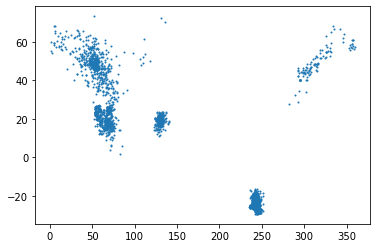

In [267]:
plt.scatter(df_no_b['ra'].values, df_no_b['dec'].values,s=1)

plt.show()

#### Chopping into sections: 1

In [268]:
df_nob_1 = df_no_b.loc[(df_no_b['dec'] < -10)]

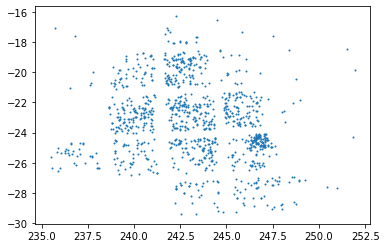

In [270]:
plt.scatter(df_nob_1['ra'].values, df_nob_1['dec'].values,s=1)

plt.show()

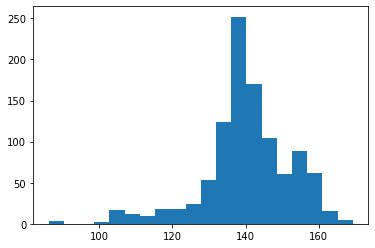

In [275]:
plt.hist(df_nob_1['dist_from_par_corr'].values,bins=20)

plt.show()

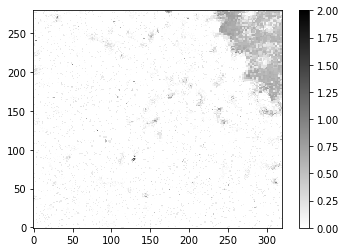

In [330]:
l0, b0 = (243., -23.)
l = np.arange(l0 - 8., l0 + 8., 0.05)
b = np.arange(b0 - 7., b0 + 7., 0.05)
l, b = np.meshgrid(l, b)
coords = SkyCoord(l*u.deg, b*u.deg,
                  distance=0.15*u.kpc, frame='icrs')
Av_bayestar = 2.742 * bayestar(coords)

plt.imshow(
    np.sqrt(Av_bayestar)[::,::-1],
    vmin=0.,
    vmax=2.,
    origin='lower',
    interpolation='nearest',
    cmap='binary',
    aspect='equal'
)


plt.colorbar()

plt.show()

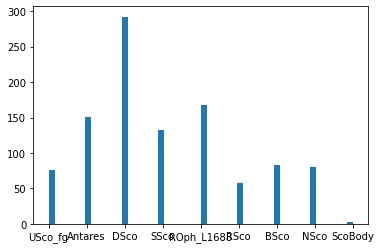

In [284]:
plt.hist(df_nob_1['cluster'].values,bins=50)

plt.show()

#### Chopping into sections: 2

In [280]:
df_nob2 = df_no_b.loc[(df_no_b['ra'] > 100) & (df_no_b['ra'] < 150) & (df_no_b['dec'] < 30)]

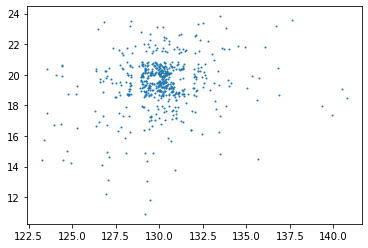

In [281]:
plt.scatter(df_nob2['ra'].values, df_nob2['dec'].values,s=1)

plt.show()

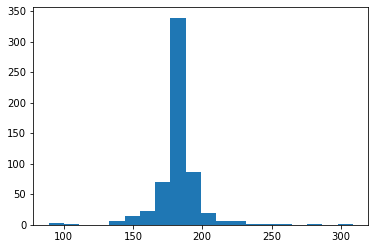

In [282]:
plt.hist(df_nob2['dist_from_par_corr'].values,bins=20)

plt.show()

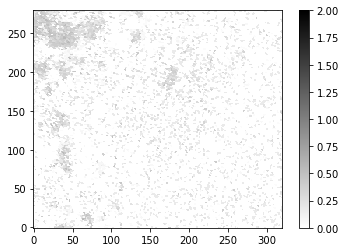

In [324]:
l0, b0 = (132., 17.)
l = np.arange(l0 - 8., l0 + 8., 0.05)
b = np.arange(b0 - 7., b0 + 7., 0.05)
l, b = np.meshgrid(l, b)
coords = SkyCoord(l*u.deg, b*u.deg,
                  distance=0.2*u.kpc, frame='icrs')
Av_bayestar = 2.742 * bayestar(coords)

plt.imshow(
    np.sqrt(Av_bayestar)[::,::-1],
    vmin=0.,
    vmax=2.,
    origin='lower',
    interpolation='nearest',
    cmap='binary',
    aspect='equal'
)

plt.colorbar()

plt.show()

#### Chopping into sections: 3

In [310]:
df_nob3 = df_no_b.loc[((df_no_b['ra'] < 100)) & (df_no_b['dec'] < 30) & (df_no_b['cluster'] == 'Pleiades')]

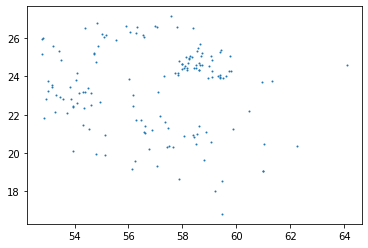

In [311]:
plt.scatter(df_nob3['ra'].values, df_nob3['dec'].values,s=1)

plt.show()

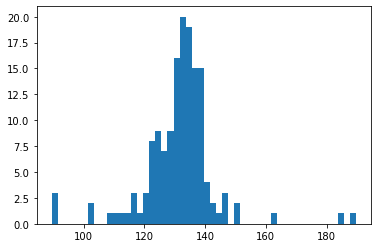

In [312]:
plt.hist(df_nob3['dist_from_par_corr'].values,bins=50)

plt.show()

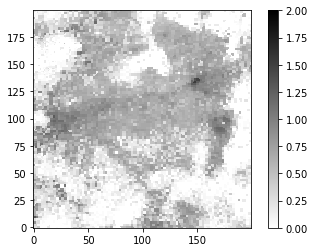

In [325]:
l0, b0 = (59., 22.)
l = np.arange(l0 - 5., l0 + 5., 0.05)
b = np.arange(b0 - 5., b0 + 5., 0.05)
l, b = np.meshgrid(l, b)
coords = SkyCoord(l*u.deg, b*u.deg,
                  distance=0.15*u.kpc, frame='icrs')
Av_bayestar = 2.742 * bayestar(coords)

plt.imshow(
    np.sqrt(Av_bayestar)[::,::-1],
    vmin=0.,
    vmax=2.,
    origin='lower',
    interpolation='nearest',
    cmap='binary',
    aspect='equal'
)

plt.colorbar()

plt.show()

#### Chopping into sections: 5 - APer

In [313]:
df_nob5 = df_no_b.loc[(df_no_b['cluster'] == 'APer')]

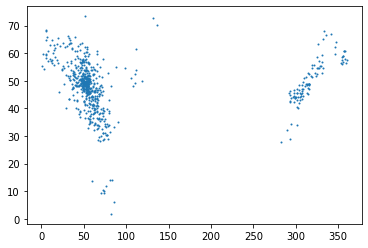

In [315]:
plt.scatter(df_nob5['ra'].values, df_nob5['dec'].values,s=1)

plt.show()

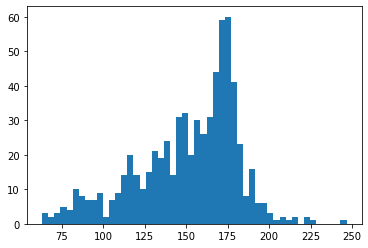

In [317]:
plt.hist(df_nob5['dist_from_par_corr'].values,bins=50)

plt.show()

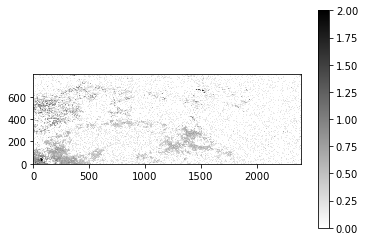

In [332]:
l0, b0 = (0., 50.)
l = np.arange(l0 - 60., l0 + 60., 0.05)
b = np.arange(b0 - 20., b0 + 20., 0.05)
l, b = np.meshgrid(l, b)
coords = SkyCoord(l*u.deg, b*u.deg,
                  distance=0.2*u.kpc, frame='icrs')
Av_bayestar = 2.742 * bayestar(coords)

plt.imshow(
    np.sqrt(Av_bayestar)[::,::-1],
    vmin=0.,
    vmax=2.,
    origin='lower',
    interpolation='nearest',
    cmap='binary',
    aspect='equal'
)

plt.colorbar()

plt.show()

### Galactic coordinates

In [226]:
coord = SkyCoord(df_no_b['ra'].values*u.deg, df_no_b['dec'].values*u.deg, distance=800*u.pc, frame='icrs')

galactic_coord = coord.galactic

# Extract galactic longitude (l) and latitude (b)
l = galactic_coord.l.degree
b = galactic_coord.b.degree

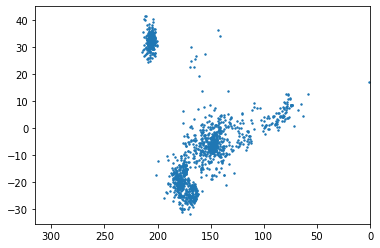

In [230]:
plt.figure

plt.scatter(l,b, s=2)

plt.xlim(315,0)

plt.show()

In [53]:
df_sub = combined_ext.loc[combined_ext['dustmap_query'] == 'both']

In [54]:
df_sub

,dr3_id,cluster,category,applied_dist_pc,dustmap_query,dustmap_theory,ra,dec,Av_b,Av_err_b,...,ARP_b,ARP_err_b,Av_e,Av_err_e,AG_e,AG_err_e,ABP_e,ABP_err_e,ARP_e,ARP_err_e
0,2128144204842804992,NGC6811,usable,1101.548290,both,both,294.557086,46.733241,0.218240,0.021713,...,0.128543,0.012819,0.124579,0.009480,0.098293,0.007505,0.124829,0.009538,0.073377,0.005606
1,2128145647951585152,NGC6811,usable,1086.496472,both,both,294.261204,46.472448,0.231987,0.069911,...,0.136640,0.041188,0.126044,0.003344,0.099448,0.002712,0.126296,0.003465,0.074240,0.002033
5,3050058075928115328,M50,unreliable_parallax,1372.814930,both,Bayestar,105.587619,-8.497584,1.090978,0.350235,...,0.642586,0.206335,0.135549,0.363200,0.106949,0.286565,0.135821,0.363927,0.079839,0.213925
6,3051541385841445248,M50,usable,1471.705257,both,Bayestar,105.885140,-8.602585,1.442485,0.109522,...,0.849624,0.064766,0.893791,0.039445,0.705201,0.031441,0.895578,0.040016,0.526443,0.023507
7,3051562787655640576,M50,unreliable_parallax,1241.016254,both,both,105.566148,-8.428145,1.145760,0.250111,...,0.674853,0.147387,0.577119,0.237805,0.455347,0.187650,0.578273,0.238314,0.339923,0.140086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10360,3426258109679969152,M35,usable,797.603070,both,both,92.198374,24.161722,0.660197,0.033290,...,0.388856,0.019785,0.441039,0.017296,0.347979,0.013824,0.441921,0.017604,0.259772,0.010339
10361,3426264191353632384,M35,usable,882.892416,both,both,92.272451,24.204979,0.682000,0.016009,...,0.401698,0.009816,0.500676,0.013272,0.395033,0.010767,0.501677,0.013753,0.294898,0.008070
10363,604974597801096064,M67,unreliable_parallax,895.421687,both,Bayestar,132.592187,12.024235,0.109120,0.017253,...,0.064272,0.010172,0.076028,0.007000,0.059986,0.005536,0.076180,0.007034,0.044780,0.004134
10372,2128099502822797952,NGC6811,usable,1047.568930,both,both,294.246591,46.098489,0.245520,0.013406,...,0.144611,0.007957,0.127787,0.006374,0.100824,0.005070,0.128042,0.006450,0.075266,0.003789


#### Just APer

In [ ]:
df_sub = df_sub.loc[(df_sub['Av_frac_err_b'] < 1) & (df_sub['Av_frac_err_e'] < 1)]

In [444]:
np.nanmedian(df_sub['Av_frac_err_b'].values)

KeyError: 'Av_frac_err_b'

In [363]:
np.nanmedian(df_sub['Av_frac_err_e'].values)

0.0644340619229018

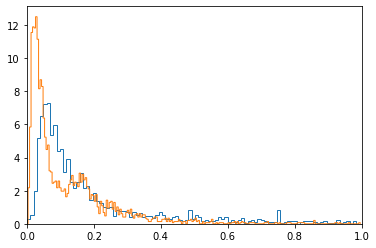

In [361]:
plt.hist(df_sub['Av_frac_err_b'].values,histtype='step',label='Bayestar',bins=100,density=True)
plt.hist(df_sub['Av_frac_err_e'].values,histtype='step',label='Edenhofer',bins=1000,density=True)



plt.xlim(0,1)

plt.show()

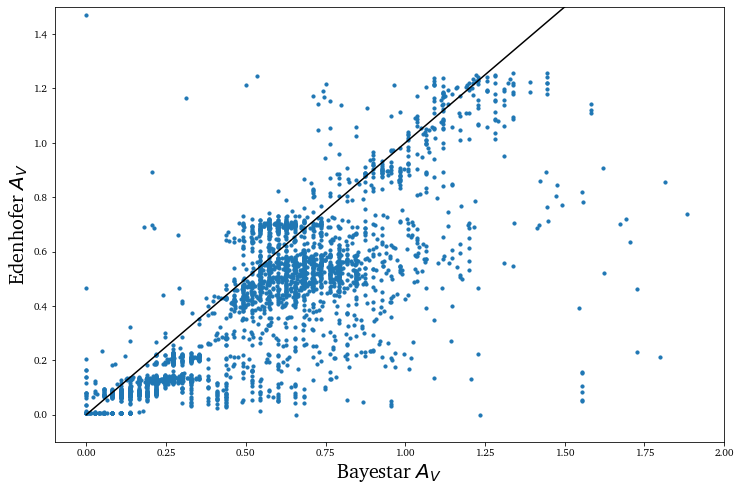

In [55]:
plt.figure(figsize=(12,8),facecolor='white')

plt.scatter(df_sub['Av_b'].values,df_sub['Av_e'].values,s=10)
plt.plot([0,10],[0,10],color='black')

plt.xlabel(r'Bayestar $A_V$',fontsize=20)
plt.ylabel(r'Edenhofer $A_V$',fontsize=20)

plt.xlim(-0.1,2)
plt.ylim(-0.1,1.5)

plt.show()

#### High latitudes

In [257]:
df_sub = df_good.loc[df_good['dustmap'] == 'both']

In [263]:
df_sub = df_sub.loc[df_sub['dec'] >= 40]

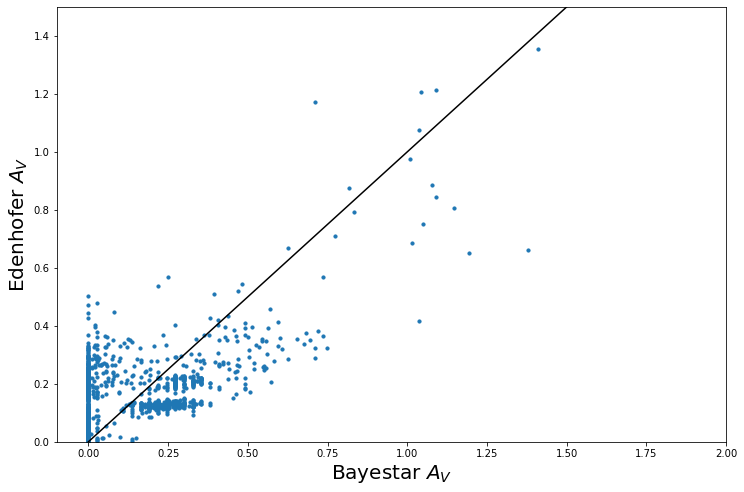

In [264]:
plt.figure(figsize=(12,8),facecolor='white')

plt.scatter(df_sub['Av_b'].values,df_sub['Av_e'].values,s=10)
plt.plot([0,10],[0,10],color='black')

plt.xlabel(r'Bayestar $A_V$',fontsize=20)
plt.ylabel(r'Edenhofer $A_V$',fontsize=20)

plt.xlim(-0.1,2)
plt.ylim(-0,1.5)

plt.show()

### Tests

In [241]:
coord = SkyCoord(241.55*u.deg, -19.65*u.deg, distance=160.1*u.pc, frame='icrs')

galactic_coord = coord.galactic

# Extract galactic longitude (l) and latitude (b)
l = galactic_coord.l.degree
b = galactic_coord.b.degree

E = bayestar(coord,mode='samples')
E

array([0.  , 0.01, 0.  , 0.  , 0.01], dtype=float32)

In [239]:
E

array([0., 0., 0., 0., 0.], dtype=float32)

In [233]:
samples_all['6245582734212097024']

{'ra': 243.550708109305,
 'dec': -19.648808466743382,
 'dist_samples': array([159.50556613, 159.52085972, 159.59345571, 159.61459518,
        159.64235574, 159.66226072, 159.78504687, 159.86403791,
        160.00446389, 160.09729388]),
 'E_samples_Bayestar': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 'E_samples_Edenhofer': array([0.20528131, 0.20520297, 0.20184482, 0.21801508, 0.20400479,
        0.20899472, 0.20997166, 0.20939831, 0.19916276, 0.21117972,
        0.21523282, 0.20342693, 0.20529182, 0.20521322, 0.20185911,
        0.21802233, 0.20401619, 0.20900385, 0.20998303, 0.20940752,
        0.19917315, 0.21118966, 0.21524205, 0.20343833, 0.20534229,
        0.20526046, 0.20192629, 0.21805652, 0.20406936, 0.20904718,
        0.21003721, 0.20945033, 0.19922215, 0.21123635, 0.21528